# EDA Import and setup

In [1]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import librosa

from scipy.signal import welch
from tqdm import tqdm

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
else:
    print('No GPU detected')

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.44 GB


# Prepare Data for EDA

In [3]:
csv_frdr = r"dataset\urban-frdr\inspections_2022.csv"
csv_zenodo = r"dataset\zenodo\state_labels.csv"
frdr_audiofolder_path = r"dataset/urban-frdr/audio_2022_all_chunk"
zenodo_audiofolder_path = r"dataset\zenodo"

In [4]:
df_frdr = pd.read_csv(csv_frdr)
target= df_frdr[(df_frdr['Queen status'] == 'queenless') | (df_frdr['Category'] == 'varroa')]
# print(target[['Date', 'Tag number', 'Category', 'Queen status']])

In [5]:
all_files = os.listdir(frdr_audiofolder_path)
extract_list = []
for file_path in all_files:
    if file_path.endswith('.wav'):
        file_name = file_path.split('/')[-1]
        parts = file_name.split('_')
        date = parts[0]
        hive_part = parts[2]
        hive_id = hive_part.split('-')[1].split('.')[0]
        for_merge = pd.to_datetime(date, format='%d-%m-%Y').strftime('%Y-%m-%d')
        extract_list.append({'Filename': file_name, 'Date': for_merge, 'Tag number': int(hive_id)})

df_audio = pd.DataFrame(extract_list)
df_audio['Tag number'] = df_audio['Tag number'].astype(int)

df_frdr['Tag number'] = df_frdr['Tag number'].astype(int)
df_frdr['Date'] = pd.to_datetime(df_frdr['Date']).dt.strftime('%Y-%m-%d')

df_frdr_sorted = df_frdr.sort_values(by=['Date', 'Tag number', 'Category'], ascending=[True, True, False])
df_frdr_clean = df_frdr_sorted.drop_duplicates(subset=['Date', 'Tag number'], keep='first')
merge_df = pd.merge(df_audio, df_frdr_clean, on=['Date', 'Tag number'], how='inner')

def check_class(row):
    if row['Category'] == 'varroa':
        return 'Class 2: Infested'
    elif row['Queen status'] == 'queenless':
        return 'Class 1: Queenless'
    elif row['Queen status'] == 'queenright' and row['Is alive'] == 1:
        return 'Class 0: Active'
    else:
        return 'Others / Ignored'
merge_df['target_Class'] = merge_df.apply(check_class, axis=1)
print(merge_df['target_Class'].value_counts())

target_Class
Class 2: Infested     162
Class 0: Active       147
Class 1: Queenless     83
Name: count, dtype: int64


In [6]:
frdr_files = glob.glob(os.path.join(frdr_audiofolder_path, "*.wav"))
frdr_data = []
for path in frdr_files:
    filename = os.path.basename(path)
    if any(suffix in filename for suffix in ["_Active", "_Queenless", "_Infested"]):
        name_part, _ = os.path.splitext(filename)
        parts = name_part.split('_')
        class_label = parts[-1]
        hive_id = "Unknown"
        for p in parts:
            if "HIVE" in p: hive_id = p; break
        frdr_data.append({'File_Path': path, 'Filename': filename, 'Dataset': 'FRDR', 'Class': class_label, 'Hive': hive_id})
df_frdr_all = pd.DataFrame(frdr_data)

zenodo_files = glob.glob(os.path.join(zenodo_audiofolder_path, "*", "*.wav"))
zenodo_data = []
for path in zenodo_files:
    filename = os.path.basename(path)
    folder_name = os.path.basename(os.path.dirname(path))
    if "NO_QueenBee" in filename: class_label = "Queenless"
    elif "QueenBee" in filename: class_label = "Active"
    else: continue
    hive_id = folder_name.split('_')[0]
    zenodo_data.append({'File_Path': path, 'Filename': filename, 'Dataset': 'ZENODO', 'Class': class_label, 'Hive': hive_id})
df_zenodo_all = pd.DataFrame(zenodo_data)

print(f"UrBAN-FRDR: {len(df_frdr_all)} Files")
print(f"Zenodo: {len(df_zenodo_all)} Files")

UrBAN-FRDR: 393 Files
Zenodo: 576 Files


In [7]:
zenodo_active_path = r"dataset\zenodo\Hive1_12_06_2018\Hive1 12_06_2018_QueenBee____00_00_00.wav"
frdr_active_path = r"dataset\urban-frdr\audio_2022_all_chunk\01-09-2022_20h30_HIVE-3693_Active.wav"

In [ ]:
sr = 16000
audio_zenodo, sr_z = librosa.load(zenodo_active_path, sr=sr)
audio_frdr, sr_f = librosa.load(frdr_active_path, sr=sr)

duration = 10
audio_zenodo = audio_zenodo[:sr * duration]
audio_frdr = audio_frdr[:sr * duration]

all_audio_files = glob.glob(r"dataset\**\*.wav", recursive=True)
all_duration_data = []
for path in all_audio_files:
    filename = os.path.basename(path)
    dataset_name = None
    filename_lower = filename.lower()
    if any(s in filename_lower for s in ["_active", "_queenless", "_infested"]):
        dataset_name = 'URBAN-FRDR'
    elif any(s in filename_lower for s in ["queenbee", "no_queenbee"]):
        dataset_name = 'ZENODO'
    if dataset_name:
        try:
            file_duration = librosa.get_duration(path=path)
            all_duration_data.append({'Dataset': dataset_name, 'Duration': file_duration})
        except:
            pass
df_durations = pd.DataFrame(all_duration_data)


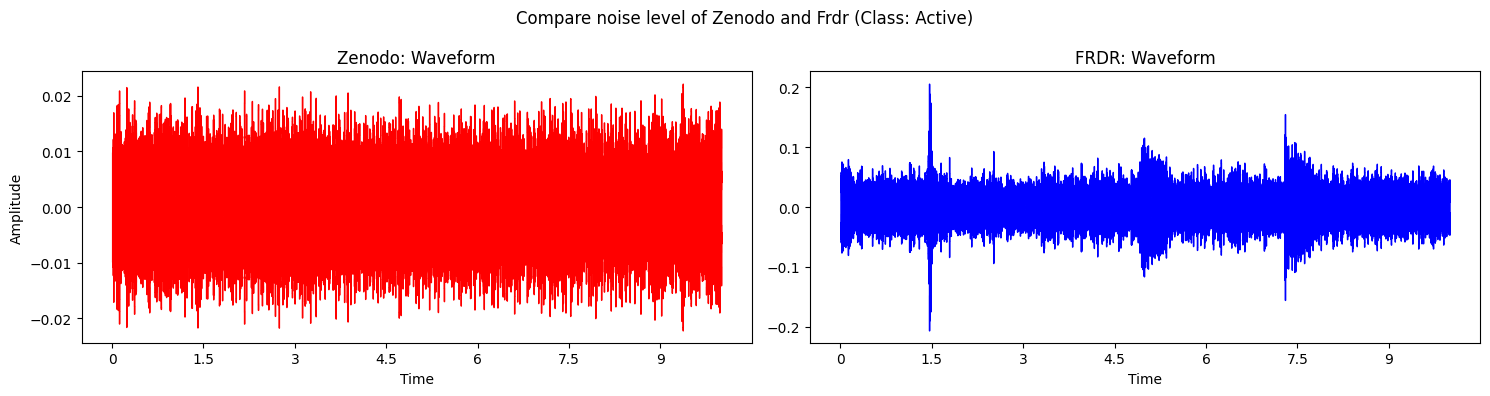

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle("Compare noise level of Zenodo and Frdr (Class: Active)")
axs[0].set_title("Zenodo: Waveform")
librosa.display.waveshow(audio_zenodo, sr=sr, ax=axs[0], color='red')
axs[0].set_ylabel("Amplitude")
axs[1].set_title("FRDR: Waveform")
librosa.display.waveshow(audio_frdr, sr=sr, ax=axs[1], color='blue')
plt.tight_layout(); plt.show()


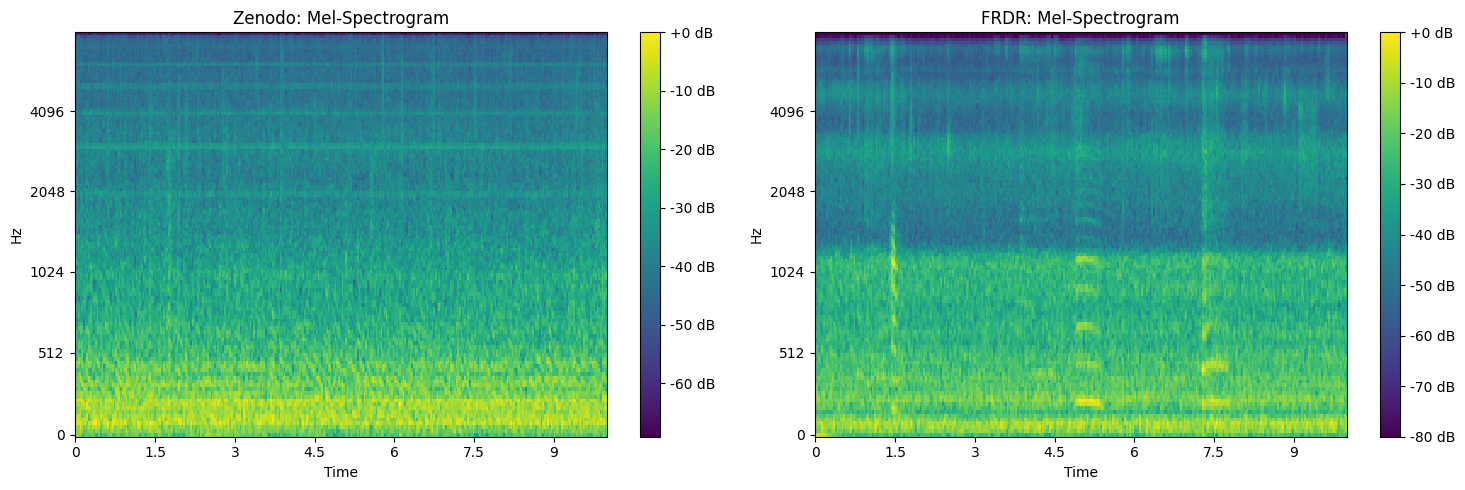

In [15]:
n_fft = 1024
hop_length = 512
audio_zenodo_norm = audio_zenodo / (np.max(np.abs(audio_zenodo)) + 1e-10)
audio_frdr_norm = audio_frdr / (np.max(np.abs(audio_frdr)) + 1e-10)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

mel_zenodo = librosa.feature.melspectrogram(y=audio_zenodo_norm, sr=sr, n_mels=128, n_fft=n_fft, hop_length=hop_length)
mel_db_zenodo = librosa.power_to_db(mel_zenodo, ref=np.max)
axs[0].set_title("Zenodo: Mel-Spectrogram")
img1 = librosa.display.specshow(mel_db_zenodo, sr=sr, x_axis='time', y_axis='mel', ax=axs[0], cmap='viridis')
fig.colorbar(img1, ax=axs[0], format='%+2.0f dB')

mel_frdr = librosa.feature.melspectrogram(y=audio_frdr_norm, sr=sr, n_mels=128, n_fft=n_fft, hop_length=hop_length)
mel_db_frdr = librosa.power_to_db(mel_frdr, ref=np.max)
axs[1].set_title("FRDR: Mel-Spectrogram")
img2 = librosa.display.specshow(mel_db_frdr, sr=sr, x_axis='time', y_axis='mel', ax=axs[1], cmap='viridis')
fig.colorbar(img2, ax=axs[1], format='%+2.0f dB')
plt.tight_layout(); plt.show()


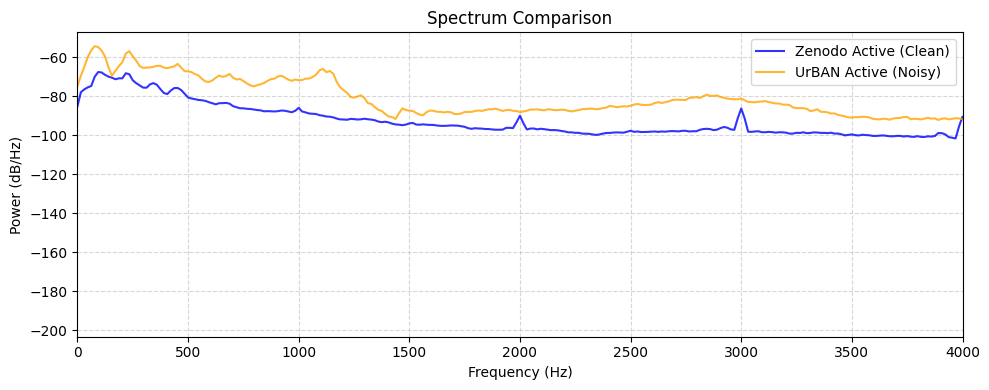

In [11]:
from scipy.signal import welch
freqs_z, psd_z = welch(audio_zenodo, sr, nperseg=1024)
freqs_u, psd_u = welch(audio_frdr, sr, nperseg=1024)

plt.figure(figsize=(10, 4))
plt.plot(freqs_z, 10 * np.log10(psd_z), label='Zenodo Active (Clean)', color='blue', alpha=0.8)
plt.plot(freqs_u, 10 * np.log10(psd_u), label='UrBAN Active (Noisy)', color='orange', alpha=0.8)
plt.title("Spectrum Comparison")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB/Hz)")
plt.xlim(0, 4000)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout(); plt.show()


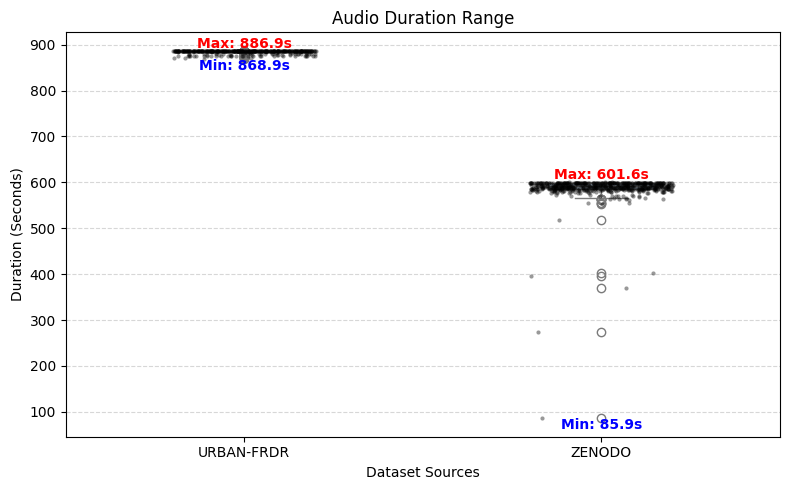

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_durations, x='Dataset', y='Duration', palette='Pastel1', width=0.3, hue='Dataset', legend=False)
sns.stripplot(data=df_durations, x='Dataset', y='Duration', color='black', size=3, alpha=0.4, jitter=0.2)

for i, dn in enumerate(['URBAN-FRDR', 'ZENODO']):
    sub = df_durations[df_durations['Dataset'] == dn]['Duration']
    if len(sub) > 0:
        plt.text(i, sub.max(), f"Max: {sub.max():.1f}s", ha='center', va='bottom', color='red', fontweight='bold', fontsize=10)
        plt.text(i, sub.min(), f"Min: {sub.min():.1f}s", ha='center', va='top', color='blue', fontweight='bold', fontsize=10)
plt.title("Audio Duration Range")
plt.xlabel("Dataset Sources")
plt.ylabel("Duration (Seconds)")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()


In [16]:
too_short = df_durations[
    (df_durations['Dataset'] == 'ZENODO') &
    (df_durations['Duration'] < 500)
]

if len(too_short) > 0:
    print(f"Too short found: {len(too_short)} File\n")
    for idx, row in too_short.iterrows():
        target_duration = row['Duration']
        for path in all_audio_files:
            if "queenbee" in path.lower() or "no_queenbee" in path.lower():
                try:
                    d = librosa.get_duration(path=path)
                    if abs(d - target_duration) < 0.1:
                        found_filename = os.path.basename(path)
                        break
                except:
                    pass
        
        print(f"File name: {found_filename}")
        print(f"Duration: {target_duration:.2f} Sec (About {target_duration/60:.1f} Min)")
else:
    print("Not found")

Too short found: 5 File

File name: Hive3_14_07_2017_NO_QueenBee____07_30_00.wav
Duration: 274.00 Sec (About 4.6 Min)
File name: Hive3_14_07_2017_NO_QueenBee____09_30_00.wav
Duration: 397.06 Sec (About 6.6 Min)
File name: Hive3_28_07_2017_QueenBee____07_40_00.wav
Duration: 369.20 Sec (About 6.2 Min)
File name: Hive3_28_07_2017_QueenBee____11_30_00.wav
Duration: 402.52 Sec (About 6.7 Min)
File name: Hive3_28_07_2017_QueenBee____12_40_00.wav
Duration: 85.91 Sec (About 1.4 Min)
